### ÜSKÜDAR ÜNİVERSİTESİ
### Yapay Zeka ve Uygulamaları
### ILHAM ASGARLI - 244312904
### Doğal Dil İşleme ile Türkçe Müşteri Yorumları Analizi

## Proje Hakkında

Bu çalışmada Türkçe müşteri yorumlarını analiz etmek için çeşitli **Doğal Dil İşleme (NLP)** teknikleri adım adım uygulanmaktadır. Türkçe, sonekler bakımından son derece zengin **çekimli (agglutinative) bir dil** olduğundan İngilizce'ye kıyasla metin ön işleme çok daha karmaşıktır.

## Kapsanan Teknikler

| # | Başlık | Yöntem |
|---|--------|--------|
| 1 | Metin Ön İşleme | NLTK, Regex, Türkçe köke indirme |
| 2 | Özellik Çıkarımı | Bag of Words, TF-IDF |
| 3 | Duygu Analizi | Naive Bayes, SVM |
| 4 | Konu Modelleme | LDA (Latent Dirichlet Allocation) |
| 5 | Model Yorumlanabilirliği | Özellik önemi, kelime bulutu, karmaşıklık matrisi |

## Veri Seti

**Hugging Face** platformundan indirilen gerçek Türkçe yorum veri seti:

- **Kaynak:** `winvoker/turkish-sentiment-analysis-dataset`
- **İçerik:** Türkçe ürün yorumları, Twitter ve Wikipedia verisi
- **Toplam:** **489.644 yorum** (Olumlu: 262K, Nötr: 170K, Olumsuz: 56K)
- **Duygu Etiketleri:** Olumlu, Olumsuz, Nötr

## Türkçe NLP Zorlukları

1. **Biçimbilimsel Zenginlik:** Türkçe tek bir kökten yüzlerce türev üretebilir (git → gitmek, gitmiş, gitmeli, giderek...)
2. **İroni / Alaycılık:** *"Harika bir ürün, tam istediğim gibi bozuldu"* → negatif ama pozitif kelimeler içeriyor
3. **Bağlam Bağımlılığı:** Aynı kelime cümle yapısına göre farklı anlam taşıyabilir
4. **Sözcük Dağarcığı Genişliği:** Türkçe internet argosunu ve yabancı kelime karışımını yönetmek zordur


In [1]:
%pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
print('Kütüphaneler başarıyla yüklendi.')

Kütüphaneler başarıyla yüklendi.


---
## 1. Veri Seti Yükleme

Veri seti **Hugging Face** üzerinden indirilmektedir.

- **Kaynak:** https://huggingface.co/datasets/winvoker/turkish-sentiment-analysis-dataset
- **İçerik:** Türkçe ürün yorumları, Twitter ve Wikipedia verisi
- **Boyut:** Tüm veri seti kullanılmaktadır — **489.644 yorum** (train + test split birleşimi)
- **Sınıflar:** Olumlu (262K), Olumsuz (56K), Nötr (170K)


In [3]:
os.makedirs('dataset', exist_ok=True)
CSV_PATH = 'dataset/turkish_reviews.csv'

if not os.path.exists(CSV_PATH):
    print('Veri seti indiriliyor: winvoker/turkish-sentiment-analysis-dataset ...')
    from datasets import load_dataset

    # Tüm train ve test splitlerini indir
    ds = load_dataset('winvoker/turkish-sentiment-analysis-dataset')

    df_train = ds['train'].to_pandas()
    df_test  = ds['test'].to_pandas()
    df_all   = pd.concat([df_train, df_test], ignore_index=True)

    df_all = df_all.rename(columns={'text': 'metin', 'label': 'duygu'})
    df_all = df_all[['metin', 'duygu']].copy()
    df_all['duygu'] = df_all['duygu'].replace(
        {'Positive': 'Olumlu', 'Negative': 'Olumsuz', 'Notr': 'Nötr'}
    )
    df_all['puan'] = df_all['duygu'].map({'Olumlu': 5, 'Nötr': 3, 'Olumsuz': 1})
    df_all = df_all[df_all['duygu'].isin(['Olumlu', 'Olumsuz', 'Nötr'])].reset_index(drop=True)
    df_all.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')
    print(f'Kaydedildi: {len(df_all):,} yorum')
else:
    print(f'Veri seti mevcut: {CSV_PATH}')

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
# Mevcut CSV'de 'Notr' olabilir — normalize et
df['duygu'] = df['duygu'].replace({'Notr': 'Nötr'})
if 'puan' not in df.columns or df['puan'].isna().any():
    df['puan'] = df['duygu'].map({'Olumlu': 5, 'Nötr': 3, 'Olumsuz': 1})
print(f'Toplam yorum : {len(df):,}')
print(f'Kaynak       : Hugging Face — winvoker/turkish-sentiment-analysis-dataset')
print(df['duygu'].value_counts().to_string())
df.head()

Veri seti mevcut: dataset/turkish_reviews.csv


Toplam yorum : 489,644
Kaynak       : Hugging Face — winvoker/turkish-sentiment-analysis-dataset
duygu
Olumlu     262166
Nötr       170917
Olumsuz     56561


,metin,duygu,puan
0,ürünü hepsiburadadan alalı 3 hafta oldu. orjin...,Olumlu,5
1,"ürünlerden çok memnunum, kesinlikle herkese ta...",Olumlu,5
2,"hızlı kargo, temiz alışveriş.teşekkür ederim.",Olumlu,5
3,Çünkü aranan tapınak bu bölgededir .,Nötr,3
4,bu telefonu başlıca alma nedenlerim ise elimde...,Olumlu,5


In [4]:
df = pd.read_csv('dataset/turkish_reviews.csv', encoding='utf-8-sig')
df['duygu'] = df['duygu'].replace({'Notr': 'Nötr'})
if 'puan' not in df.columns or df['puan'].isna().any():
    df['puan'] = df['duygu'].map({'Olumlu': 5, 'Nötr': 3, 'Olumsuz': 1})
print(f'Boyut: {df.shape}')
print(f'Sütunlar: {list(df.columns)}')
print('Veri tipleri:')
print(df.dtypes)
print('Eksik değer:')
print(df.isnull().sum())
print('Duygu dağılımı:')
print(df['duygu'].value_counts())

Boyut: (489644, 3)
Sütunlar: ['metin', 'duygu', 'puan']
Veri tipleri:
metin      str
duygu      str
puan     int64
dtype: object
Eksik değer:
metin    0
duygu    0
puan     0
dtype: int64
Duygu dağılımı:
duygu
Olumlu     262166
Nötr       170917
Olumsuz     56561
Name: count, dtype: int64


---
## 2. Keşifsel Veri Analizi (EDA)

Veri setini görsel olarak inceliyoruz: duygu dağılımı, yorum uzunluğu ve puan dağılımı.


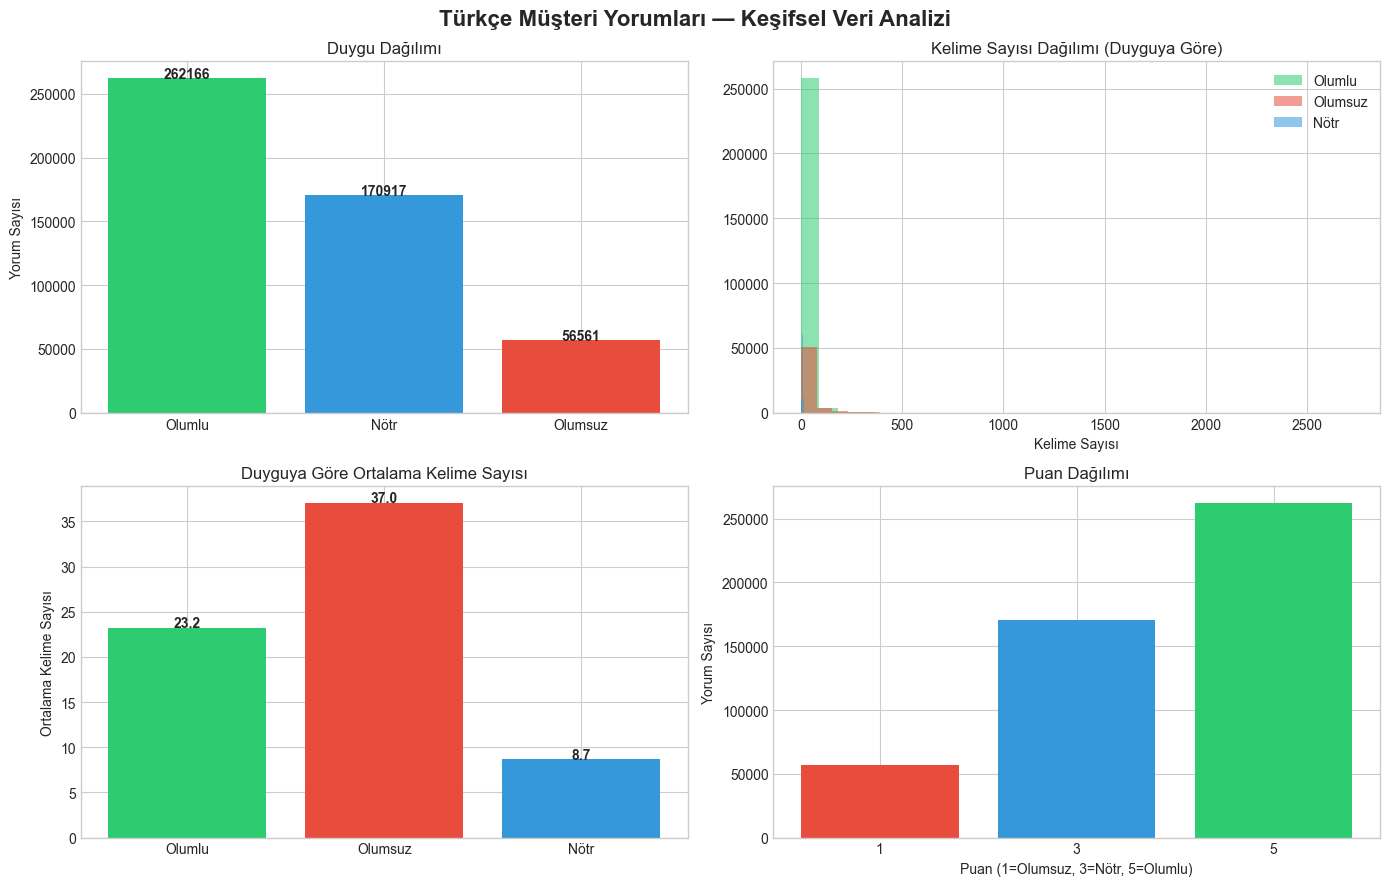


--- Kelime Sayisi Istatistikleri ---
            count   mean    std  min   25%   50%   75%     max
duygu                                                         
Nötr     170917.0   8.65   3.02  1.0   6.0   8.0  11.0    92.0
Olumlu   262166.0  23.22  24.93  1.0   9.0  19.0  29.0  2724.0
Olumsuz   56561.0  37.03  53.93  1.0  11.0  22.0  41.0  2329.0


In [5]:
df['yorum_uzunlugu'] = df['metin'].apply(len)
df['kelime_sayisi'] = df['metin'].apply(lambda x: len(str(x).split()))

RENKLER = {'Olumlu': '#2ecc71', 'Olumsuz': '#e74c3c', 'Nötr': '#3498db'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Türkçe Müşteri Yorumları — Keşifsel Veri Analizi', fontsize=16, fontweight='bold')

# Duygu dağılımı
duygu_sayilari = df['duygu'].value_counts()
axes[0, 0].bar(duygu_sayilari.index, duygu_sayilari.values,
               color=[RENKLER.get(d, '#95a5a6') for d in duygu_sayilari.index])
axes[0, 0].set_title('Duygu Dağılımı')
axes[0, 0].set_ylabel('Yorum Sayısı')
for i, v in enumerate(duygu_sayilari.values):
    axes[0, 0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Kelime sayısı dağılımı (duyguya göre)
for duygu, renk in RENKLER.items():
    alt = df[df['duygu'] == duygu]['kelime_sayisi']
    if len(alt):
        axes[0, 1].hist(alt, alpha=0.55, color=renk, label=duygu, bins=30)
axes[0, 1].set_title('Kelime Sayısı Dağılımı (Duyguya Göre)')
axes[0, 1].set_xlabel('Kelime Sayısı')
axes[0, 1].legend()

# Ortalama kelime sayısı
ort_kelime = df.groupby('duygu')['kelime_sayisi'].mean().reindex(list(RENKLER.keys()))
bars = axes[1, 0].bar(ort_kelime.index, ort_kelime.values,
                      color=[RENKLER[d] for d in ort_kelime.index])
axes[1, 0].set_title('Duyguya Göre Ortalama Kelime Sayısı')
axes[1, 0].set_ylabel('Ortalama Kelime Sayısı')
for bar, val in zip(bars, ort_kelime.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.1f}', ha='center', fontweight='bold')

# Puan dağılımı
puan_sayilari = df['puan'].value_counts().sort_index()
axes[1, 1].bar(puan_sayilari.index.astype(str), puan_sayilari.values,
               color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1, 1].set_title('Puan Dağılımı')
axes[1, 1].set_xlabel('Puan (1=Olumsuz, 3=Nötr, 5=Olumlu)')
axes[1, 1].set_ylabel('Yorum Sayısı')

plt.tight_layout()
plt.show()

print()
print('--- Kelime Sayisi Istatistikleri ---')
print(df.groupby('duygu')['kelime_sayisi'].describe().round(2))

---
## 3. Metin Ön İşleme (Text Preprocessing)

Türkçe metinler için özelleştirilmiş ön işleme adımları:

1. **Küçük harfe dönüştürme** — `İ → i`, `Ş → ş` gibi Türkçe karakterler doğru işlenir
2. **URL, e-posta, özel karakter temizleme** — Regex tabanlı
3. **Sayı kaldırma** — Sayısal ifadeler NLP'de genellikle gürültüdür
4. **Tokenizasyon** — NLTK ile kelimeye bölme
5. **Türkçe durak kelime kaldırma** — NLTK Turkish stop words
6. **Köke indirme (stemming)** — Türkçe yaygın sonekleri kaldıran basit bir algoritma

> **Not:** Türkçe çekimli bir dil olduğundan "gitmek", "gitmiş", "gidecek", "gidebilir" gibi yüzlerce türev aynı kökten üretilir. Bu nedenle köke indirme İngilizce'den çok daha kritiktir.


In [6]:
try:
    turkce_durak = set(stopwords.words('turkish'))
except OSError:
    turkce_durak = set()

ek_durak = {
    'bir', 'bu', 'şu', 'o', 'biz', 'siz', 'onlar', 'ben', 'sen',
    've', 'ile', 'veya', 'ama', 'fakat', 'ancak', 'çünkü', 'için',
    'gibi', 'kadar', 'daha', 'en', 'çok', 'az', 'da', 'de', 'mi',
    'mı', 'mu', 'mü', 'ki', 'ya', 'ne', 'nasıl', 'nerede', 'hangi',
    'kim', 'hem', 'bile', 'hatta', 'hiç', 'hiçbir', 'bazı', 'biraz',
    'birkaç', 'bütün', 'hep', 'herkes', 'her', 'tüm', 'kendi', 'öyle',
    'böyle', 'şöyle', 'niye', 'niçin', 'neden', 'ayrıca', 'özellikle',
    'genellikle', 'sadece', 'yalnızca', 'zaten', 'artık', 'hâlâ',
    'hala', 'yine', 'tekrar', 'gene', 'önce', 'sonra', 'şimdi',
    'bugün', 'dün', 'yarın', 'bazen', 'nadiren', 'çeşitli', 'birçok',
    'çok', 'gerçekten', 'kesinlikle', 'tamamen', 'oldukça', 'gayet',
}
turkce_durak.update(ek_durak)

TURKCE_SONEKLER = sorted([
    'ların', 'lerin', 'larım', 'lerim', 'larını', 'lerini',
    'lardan', 'lerden', 'larda', 'lerde', 'lara', 'lere',
    'ların', 'lerin', 'lar', 'ler',
    'ından', 'inden', 'undan', 'ünden', 'ndan', 'nden',
    'ında', 'inde', 'unda', 'ünde', 'nda', 'nde',
    'ına', 'ine', 'una', 'üne', 'na', 'ne',
    'dan', 'den', 'tan', 'ten',
    'da', 'de', 'ta', 'te',
    'ıyor', 'iyor', 'uyor', 'üyor',
    'acak', 'ecek', 'mak', 'mek',
    'arak', 'erek',
    'mış', 'miş', 'muş', 'müş',
    'dı', 'di', 'du', 'dü', 'tı', 'ti', 'tu', 'tü',
    'ım', 'im', 'um', 'üm',
    'ın', 'in', 'un', 'ün',
    'lık', 'lik', 'luk', 'lük',
    'lı', 'li', 'lu', 'lü',
    'sız', 'siz', 'suz', 'süz',
    'cı', 'ci', 'cu', 'cü', 'çı', 'çi', 'çu', 'çü',
    'ı', 'i', 'u', 'ü',
    'a', 'e',
    'ken', 'ki',
], key=len, reverse=True)


def turkce_kok_bul(kelime):
    """Türkçe yaygın sonekleri kaldırarak köke yaklaşır."""
    for sonek in TURKCE_SONEKLER:
        if kelime.endswith(sonek) and len(kelime) - len(sonek) >= 3:
            return kelime[:-len(sonek)]
    return kelime


def metin_on_isle(metin, stemming=True):
    """Türkçe metin için tam ön işleme pipeline'ı."""
    metin = metin.replace('İ', 'i').replace('I', 'ı')
    metin = metin.lower()
    metin = re.sub(r'http\S+|www\S+|\S+@\S+', ' ', metin)
    metin = re.sub(r'<[^>]+>', ' ', metin)
    metin = re.sub(r'\d+', ' ', metin)
    metin = re.sub(r'[^\w\sğüşıöçĞÜŞİÖÇ]', ' ', metin)
    metin = re.sub(r'\s+', ' ', metin).strip()
    kelimeler = metin.split()
    kelimeler = [k for k in kelimeler if k not in turkce_durak and len(k) >= 3]
    if stemming:
        kelimeler = [turkce_kok_bul(k) for k in kelimeler]
    return ' '.join(kelimeler)


print('Ön işleme fonksiyonları tanımlandı.')
print(f'Toplam Türkçe durak kelime sayısı: {len(turkce_durak)}')

ornek = "Bu ürün gerçekten harika! Kamera kalitesi çok iyi, batarya ömrü de uzun."
print(f'\nÖrnek metin   : {ornek}')
print(f'İşlenmiş metin: {metin_on_isle(ornek)}')

Ön işleme fonksiyonları tanımlandı.
Toplam Türkçe durak kelime sayısı: 99

Örnek metin   : Bu ürün gerçekten harika! Kamera kalitesi çok iyi, batarya ömrü de uzun.
İşlenmiş metin: ürün harik kamer kalites iyi batary ömr uzun


In [7]:
df['islenmis'] = df['metin'].apply(metin_on_isle)

print('Ön işleme tamamlandı. Karşılaştırma örnekleri:')
print('=' * 80)
for _, row in df.sample(5, random_state=RANDOM_STATE).iterrows():
    print(f'[{row["duygu"]}]')
    metin_k = row['metin']
    print(f'  Ham    : {metin_k[:90]}...' if len(metin_k) > 90 else f'  Ham    : {metin_k}')
    print(f'  İşlenmiş: {row["islenmis"]}')
    print()


Ön işleme tamamlandı. Karşılaştırma örnekleri:
[Nötr]
  Ham    : Lut Gölü gibi kapalı havza denizlerde ise tuzluluk kayda değer derecede daha fazladır .
  İşlenmiş: lut göl kapa havz deniz tuzlu kay değer derece fazladır

[Nötr]
  Ham    : Biz kararlılık ile devam ediyoruz .
  İşlenmiş: kararlı devam ediyoruz

[Olumlu]
  Ham    : ürünü eşim için almıştık ve oldukça memnun kaldık. fiyatına göre oldukça kelteli bir ürün....
  İşlenmiş: ürün eşim almıştık memn kaldık fiyat gör kelte ürün kumaşın yüzey dış yüzey yap olarak fark kargon bedav olmas artılar aras beden çizelges gör aldık eşim üst tam otur tavsiy eder

[Olumsuz]
  Ham    :  Tüm harcadıkları emek ne yazık ki boşa gitmiş...İzlerken sinir krizi geçirilebilecek bir ...
  İşlenmiş: harcadıklar emek yazık boş git izler sinir kriz geçirilebil film olduğ hastahane gösterim girmeliy

[Nötr]
  Ham    : Revan Seferine katıldı .
  İşlenmiş: revan sefer katıl



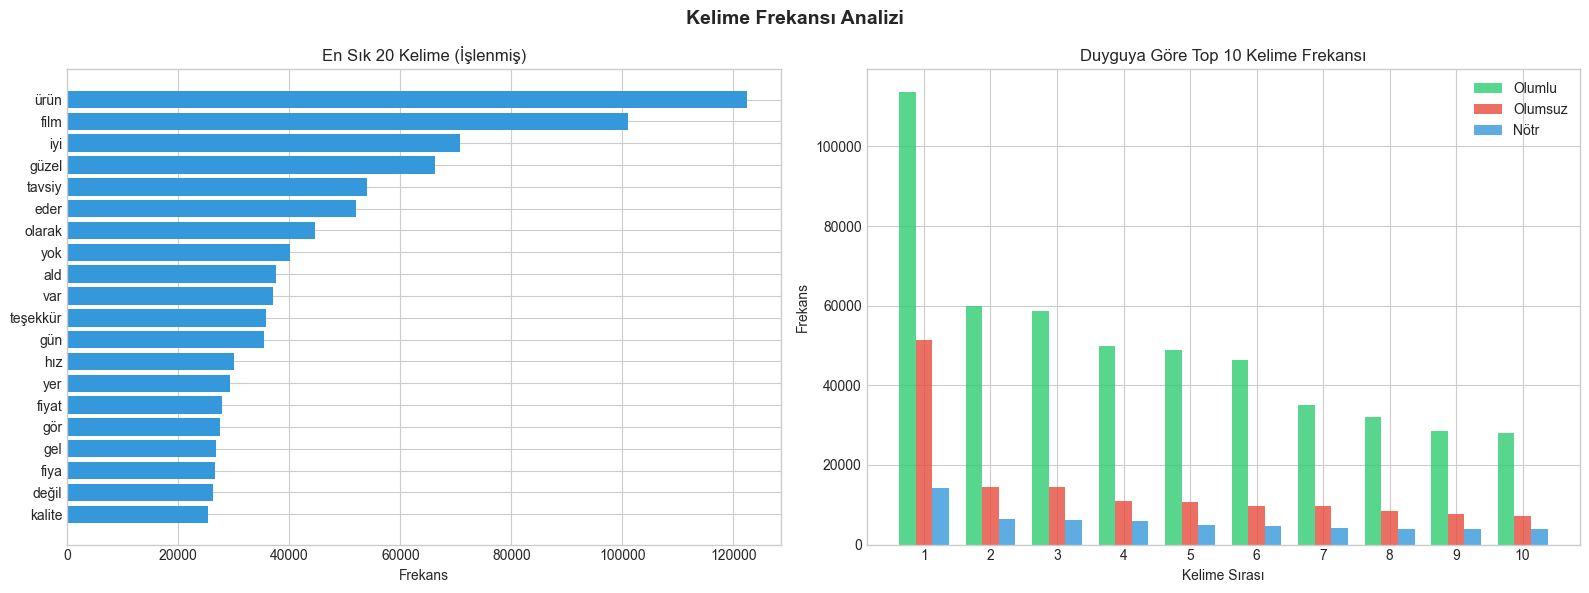

In [8]:
# En sık kullanılan kelimeler (işlenmiş metin)
tum_kelimeler = ' '.join(df['islenmis']).split()
kelime_freq = Counter(tum_kelimeler)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Kelime Frekansı Analizi', fontsize=14, fontweight='bold')

# Genel top 20
en_sik = kelime_freq.most_common(20)
kelimeler_lst = [k for k, _ in en_sik]
frekanslar = [f for _, f in en_sik]
axes[0].barh(kelimeler_lst[::-1], frekanslar[::-1], color='#3498db')
axes[0].set_title('En Sık 20 Kelime (İşlenmiş)')
axes[0].set_xlabel('Frekans')

# Duyguya göre ayrı top 10
renkler = {'Olumlu': '#2ecc71', 'Olumsuz': '#e74c3c', 'Nötr': '#3498db'}
x = np.arange(10)
genislik = 0.25
for idx, (duygu, renk) in enumerate(renkler.items()):
    alt_df = df[df['duygu'] == duygu]
    kelimeler_d = ' '.join(alt_df['islenmis']).split()
    en_sik_d = Counter(kelimeler_d).most_common(10)
    frekanslar_d = [f for _, f in en_sik_d]
    axes[1].bar(x + idx * genislik, frekanslar_d, genislik, label=duygu, color=renk, alpha=0.8)

axes[1].set_title('Duyguya Göre Top 10 Kelime Frekansı')
axes[1].set_xlabel('Kelime Sırası')
axes[1].set_ylabel('Frekans')
axes[1].legend()
axes[1].set_xticks(x + genislik)
axes[1].set_xticklabels([str(i + 1) for i in range(10)])

plt.tight_layout()
plt.show()

---
## 4. Özellik Çıkarımı (Feature Extraction)

### 4.1 Bag of Words (Kelime Torbası)

Bag of Words yönteminde her belge, sözcük dağarcığındaki kelimelerin **frekanslarını** içeren bir vektörle temsil edilir. Kelime sırası ve bağlamı **göz ardı edilir**.

$$\text{BoW}(d, w) = \text{count}(w, d)$$

**Avantajlar:** Basit, hızlı, yorumlanabilir  
**Dezavantajlar:** Kelime sırası yok, yaygın kelimeler çok ağırlık kazanır

### 4.2 TF-IDF (Terim Frekansı – Ters Belge Frekansı)

TF-IDF her kelimenin **bilgi taşıma değerini** ölçer:

$$\text{TF-IDF}(t, d) = \text{TF}(t,d) \times \log\frac{N}{1 + \text{DF}(t)}$$

- **TF:** Kelimenin o belgede ne kadar sık geçtiği
- **IDF:** Kelimenin kaç belgede geçtiğinin tersi (yaygın kelimeleri cezalandırır)

**Avantajlar:** Yaygın ama anlamsız kelimeleri bastırır, daha bilgilendirici  
**Dezavantajlar:** Hâlâ kelime sırası/bağlamı yok


Bag of Words Matrisi:
  Boyut       : (489644, 500)  (489644 belge × 500 özellik)
  Sıfır olmayan: 3,246,472 / 244,822,000 (1.33% dolu)
  Örnek özellikler: ['adam', 'adet', 'adı', 'akşam', 'ala', 'alabilirsiniz', 'alacak', 'alan', 'ald', 'aldık', 'aldığ', 'alma', 'almak', 'almay', 'almış', 'almışt', 'alt', 'alın', 'alıp', 'alır']


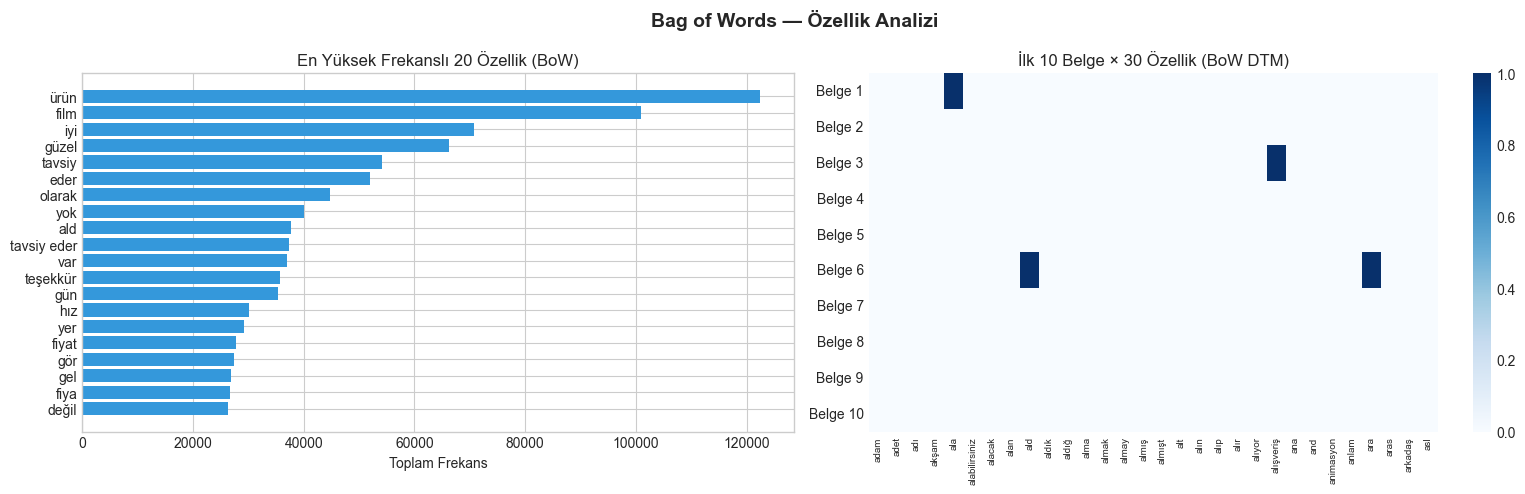

In [9]:
# ===== BAG OF WORDS =====
bow_vec = CountVectorizer(max_features=500, min_df=2, max_df=0.95, ngram_range=(1, 2))
X_bow = bow_vec.fit_transform(df['islenmis'])

print('Bag of Words Matrisi:')
print(f'  Boyut       : {X_bow.shape}  ({X_bow.shape[0]} belge × {X_bow.shape[1]} özellik)')
print(f'  Sıfır olmayan: {X_bow.nnz:,} / {X_bow.shape[0] * X_bow.shape[1]:,} ({100*X_bow.nnz/(X_bow.shape[0]*X_bow.shape[1]):.2f}% dolu)')
print(f'  Örnek özellikler: {bow_vec.get_feature_names_out()[:20].tolist()}')

# En yüksek frekansı olan özellikler
toplam_frekans = np.array(X_bow.sum(axis=0)).flatten()
en_yuksek_idx = toplam_frekans.argsort()[::-1][:20]
en_yuksek_kelimeler = bow_vec.get_feature_names_out()[en_yuksek_idx]
en_yuksek_frekanslar = toplam_frekans[en_yuksek_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Bag of Words — Özellik Analizi', fontsize=14, fontweight='bold')

axes[0].barh(en_yuksek_kelimeler[::-1], en_yuksek_frekanslar[::-1], color='#3498db')
axes[0].set_title('En Yüksek Frekanslı 20 Özellik (BoW)')
axes[0].set_xlabel('Toplam Frekans')

# Belge-terim matrisinin görselleştirilmesi (ilk 10 belge × 30 özellik)
sample_dtm = X_bow[:10, :30].toarray()
sns.heatmap(sample_dtm, ax=axes[1], cmap='Blues',
            xticklabels=bow_vec.get_feature_names_out()[:30],
            yticklabels=[f'Belge {i+1}' for i in range(10)])
axes[1].set_title('İlk 10 Belge × 30 Özellik (BoW DTM)')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

TF-IDF Matrisi:
  Boyut       : (489644, 500)
  Sıfır olmayan: 3,246,472


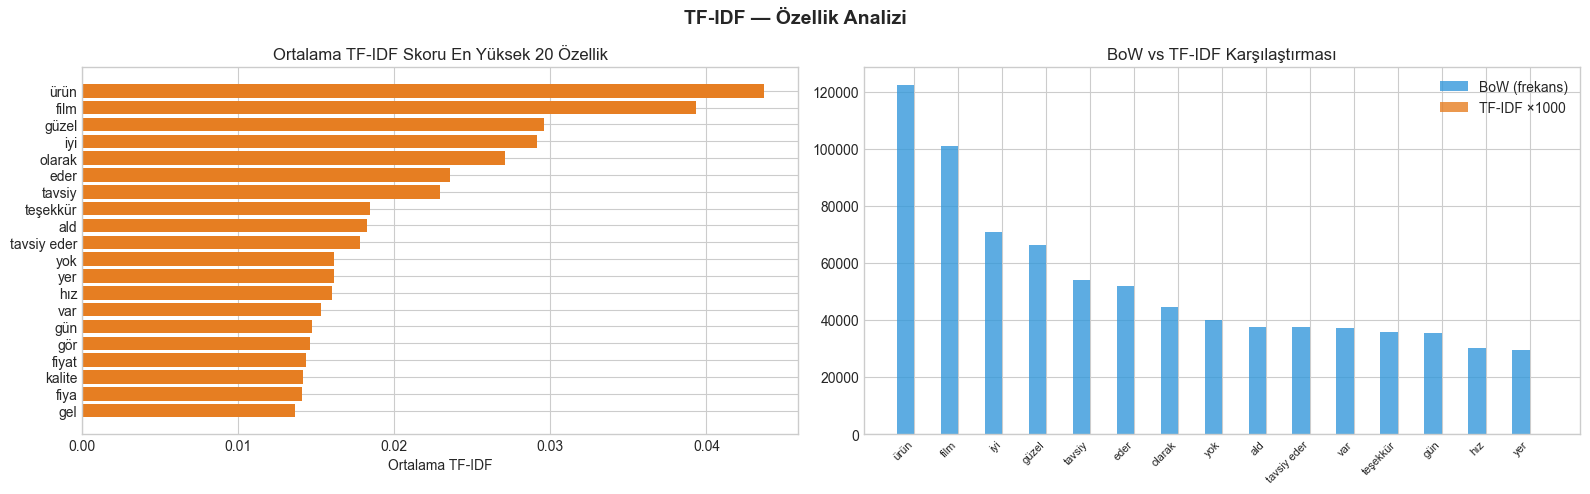

In [10]:
# ===== TF-IDF =====
tfidf_vec = TfidfVectorizer(max_features=500, min_df=2, max_df=0.95, ngram_range=(1, 2))
X_tfidf = tfidf_vec.fit_transform(df['islenmis'])

print('TF-IDF Matrisi:')
print(f'  Boyut       : {X_tfidf.shape}')
print(f'  Sıfır olmayan: {X_tfidf.nnz:,}')

# TF-IDF skoru en yüksek kelimeler
ortalama_tfidf = np.array(X_tfidf.mean(axis=0)).flatten()
en_yuksek_tfidf_idx = ortalama_tfidf.argsort()[::-1][:20]
en_yuksek_tfidf_kelimeler = tfidf_vec.get_feature_names_out()[en_yuksek_tfidf_idx]
en_yuksek_tfidf_skorlar = ortalama_tfidf[en_yuksek_tfidf_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('TF-IDF — Özellik Analizi', fontsize=14, fontweight='bold')

axes[0].barh(en_yuksek_tfidf_kelimeler[::-1], en_yuksek_tfidf_skorlar[::-1], color='#e67e22')
axes[0].set_title('Ortalama TF-IDF Skoru En Yüksek 20 Özellik')
axes[0].set_xlabel('Ortalama TF-IDF')

# BoW vs TF-IDF karşılaştırması — ilk 15 özellik
ortak = [k for k in en_yuksek_kelimeler[:15] if k in tfidf_vec.vocabulary_]
bow_skorlar = [toplam_frekans[bow_vec.vocabulary_[k]] for k in ortak]
tfidf_skorlar = [ortalama_tfidf[tfidf_vec.vocabulary_[k]] * 1000 for k in ortak]

x_pos = np.arange(len(ortak))
axes[1].bar(x_pos - 0.2, bow_skorlar, 0.4, label='BoW (frekans)', color='#3498db', alpha=0.8)
axes[1].bar(x_pos + 0.2, tfidf_skorlar, 0.4, label='TF-IDF ×1000', color='#e67e22', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ortak, rotation=45, ha='right', fontsize=8)
axes[1].set_title('BoW vs TF-IDF Karşılaştırması')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Duygu Analizi: Naive Bayes

**Multinomial Naive Bayes**, metin sınıflandırması için çok yaygın kullanılan istatistiksel bir modeldir.

$$P(\text{sınıf}|\text{metin}) \propto P(\text{sınıf}) \prod_{w \in \text{metin}} P(w|\text{sınıf})$$

- **Avantajlar:** Hızlı, az veriye iyi uyum sağlar, yorumlanabilir  
- **Dezavantajlar:** Özellikler arasındaki bağımsızlık varsayımı gerçekçi değil

Hem Bag of Words hem TF-IDF özellikleriyle denenecektir.


In [11]:
le = LabelEncoder()
y = le.fit_transform(df['duygu'])
print('Sınıf kodlaması:', dict(zip(le.classes_, le.transform(le.classes_))))

# İkili sınıflandırma (Olumlu vs Olumsuz) için alt küme
df_bin = df[df['duygu'].isin(['Olumlu', 'Olumsuz'])].copy().reset_index(drop=True)
y_bin = (df_bin['duygu'] == 'Olumlu').astype(int)

# Çoklu sınıf (3 sınıf)
X_tr_bow, X_te_bow, y_tr, y_te = train_test_split(
    X_bow, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_tr_tfidf, X_te_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'\nEğitim seti: {X_tr_bow.shape[0]} örnek')
print(f'Test seti  : {X_te_bow.shape[0]} örnek')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sonuclar = {}

# ---- Naive Bayes + BoW ----
nb_bow = MultinomialNB(alpha=0.5)
nb_bow.fit(X_tr_bow, y_tr)
y_pred_nb_bow = nb_bow.predict(X_te_bow)
cv_nb_bow = cross_val_score(MultinomialNB(alpha=0.5), X_bow, y, cv=skf, scoring='accuracy')
sonuclar['NB + BoW'] = {
    'test_acc': accuracy_score(y_te, y_pred_nb_bow),
    'cv_mean': cv_nb_bow.mean(),
    'cv_std': cv_nb_bow.std(),
    'y_pred': y_pred_nb_bow,
}

# ---- Naive Bayes + TF-IDF ----
nb_tfidf = MultinomialNB(alpha=0.5)
nb_tfidf.fit(X_tr_tfidf, y_tr)
y_pred_nb_tfidf = nb_tfidf.predict(X_te_tfidf)
cv_nb_tfidf = cross_val_score(MultinomialNB(alpha=0.5), X_tfidf, y, cv=skf, scoring='accuracy')
sonuclar['NB + TF-IDF'] = {
    'test_acc': accuracy_score(y_te, y_pred_nb_tfidf),
    'cv_mean': cv_nb_tfidf.mean(),
    'cv_std': cv_nb_tfidf.std(),
    'y_pred': y_pred_nb_tfidf,
}

print('\n--- Naive Bayes Sonuçları ---')
for isim, s in sonuclar.items():
    print(f'{isim:20s} | Test Doğruluk: {s["test_acc"]:.3f} | CV: {s["cv_mean"]:.3f} ± {s["cv_std"]:.3f}')

print('\n--- NB + TF-IDF Sınıflandırma Raporu ---')
print(classification_report(y_te, y_pred_nb_tfidf, target_names=le.classes_))

Sınıf kodlaması: {'Nötr': np.int64(0), 'Olumlu': np.int64(1), 'Olumsuz': np.int64(2)}



Eğitim seti: 391715 örnek
Test seti  : 97929 örnek



--- Naive Bayes Sonuçları ---
NB + BoW             | Test Doğruluk: 0.777 | CV: 0.776 ± 0.002
NB + TF-IDF          | Test Doğruluk: 0.787 | CV: 0.786 ± 0.001

--- NB + TF-IDF Sınıflandırma Raporu ---


              precision    recall  f1-score   support

        Nötr       0.89      0.68      0.77     34184
      Olumlu       0.76      0.93      0.83     52433
     Olumsuz       0.70      0.46      0.55     11312

    accuracy                           0.79     97929
   macro avg       0.78      0.69      0.72     97929
weighted avg       0.80      0.79      0.78     97929



---
## 6. Duygu Analizi: Support Vector Machine (SVM)

**Linear SVM (LinearSVC)**, yüksek boyutlu seyrek metin özelliklerinde çok başarılı bir sınıflandırıcıdır. Maksimum marjin prensibiyle sınıfları ayıran en iyi hiper düzlemi bulur.

$$\min_{w,b} \frac{1}{2}\|w\|^2 + C\sum_{i}\max(0, 1 - y_i(w \cdot x_i + b))$$

- **Avantajlar:** Yüksek boyutlu uzayda etkili, aşırı öğrenmeye dirençli  
- **Dezavantajlar:** Parametreye duyarlı, olasılık çıktısı vermez


In [12]:
# ---- SVM + BoW ----
svm_bow = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
svm_bow.fit(X_tr_bow, y_tr)
y_pred_svm_bow = svm_bow.predict(X_te_bow)
cv_svm_bow = cross_val_score(LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
                              X_bow, y, cv=skf, scoring='accuracy')
sonuclar['SVM + BoW'] = {
    'test_acc': accuracy_score(y_te, y_pred_svm_bow),
    'cv_mean': cv_svm_bow.mean(),
    'cv_std': cv_svm_bow.std(),
    'y_pred': y_pred_svm_bow,
}

# ---- SVM + TF-IDF ----
svm_tfidf = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
svm_tfidf.fit(X_tr_tfidf, y_tr)
y_pred_svm_tfidf = svm_tfidf.predict(X_te_tfidf)
cv_svm_tfidf = cross_val_score(LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
                                X_tfidf, y, cv=skf, scoring='accuracy')
sonuclar['SVM + TF-IDF'] = {
    'test_acc': accuracy_score(y_te, y_pred_svm_tfidf),
    'cv_mean': cv_svm_tfidf.mean(),
    'cv_std': cv_svm_tfidf.std(),
    'y_pred': y_pred_svm_tfidf,
}

print('--- SVM Sonuçları ---')
for isim in ['SVM + BoW', 'SVM + TF-IDF']:
    s = sonuclar[isim]
    print(f'{isim:20s} | Test Doğruluk: {s["test_acc"]:.3f} | CV: {s["cv_mean"]:.3f} ± {s["cv_std"]:.3f}')

print('\n--- SVM + TF-IDF Sınıflandırma Raporu ---')
print(classification_report(y_te, y_pred_svm_tfidf, target_names=le.classes_))

--- SVM Sonuçları ---
SVM + BoW            | Test Doğruluk: 0.878 | CV: 0.878 ± 0.001
SVM + TF-IDF         | Test Doğruluk: 0.876 | CV: 0.875 ± 0.001

--- SVM + TF-IDF Sınıflandırma Raporu ---
              precision    recall  f1-score   support

        Nötr       0.86      0.96      0.91     34184
      Olumlu       0.90      0.90      0.90     52433
     Olumsuz       0.75      0.50      0.60     11312

    accuracy                           0.88     97929
   macro avg       0.84      0.79      0.80     97929
weighted avg       0.87      0.88      0.87     97929



---
## 7. Konu Modelleme: LDA (Latent Dirichlet Allocation)

**LDA**, belgelerde gizli **konu yapılarını** keşfeden istatistiksel bir modeldir. Her belge birden fazla konunun karışımından oluştuğu varsayılır.

- **Giriş:** İşlenmiş metinlerin belge-terim matrisi
- **Çıkış:** K adet konu; her konu, kelimelerin bir olasılık dağılımıdır

Veri setindeki anlamlı konu ayrımı için **K=5 konu** seçilmiştir.


In [13]:
# LDA için alt örneklem — 492K satırla LDA çok yavaş olur
LDA_SAMPLE = min(20_000, len(df))
df_lda = df.sample(LDA_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

lda_vec = CountVectorizer(max_features=1000, min_df=3, max_df=0.90)
X_lda = lda_vec.fit_transform(df_lda['islenmis'])
lda_ozellikler = lda_vec.get_feature_names_out()

N_KONU = 5
lda_model = LatentDirichletAllocation(
    n_components=N_KONU,
    max_iter=20,
    learning_method='online',
    random_state=RANDOM_STATE,
    doc_topic_prior=0.1,
    topic_word_prior=0.01,
    n_jobs=-1,
)
lda_model.fit(X_lda)

N_UST_KELIME = 12
print(f'LDA modeli eğitildi — {N_KONU} konu, {N_UST_KELIME} üst kelime/konu')
print(f'(Alt örneklem: {LDA_SAMPLE:,} yorum kullanıldı)')
print('=' * 70)
for konu_idx, konu_dagilimi in enumerate(lda_model.components_):
    ust_kelimeler = [lda_ozellikler[i] for i in konu_dagilimi.argsort()[::-1][:N_UST_KELIME]]
    print(f'Konu {konu_idx + 1}: {", ".join(ust_kelimeler)}')


LDA modeli eğitildi — 5 konu, 12 üst kelime/konu
(Alt örneklem: 20,000 yorum kullanıldı)
Konu 1: ürün, güzel, iyi, eder, teşekkür, tavsiy, ald, hız, fiyat, fiya, gün, kalite
Konu 2: telefon, iki, olarak, büyük, üzer, şarj, taraf, ses, var, yok, cihaz, par
Konu 3: film, son, iyi, ilk, güzel, köt, benc, zaman, olan, değil, yer, insan
Konu 4: tavsiy, eder, harik, herkes, gerek, güzel, yok, ayn, mükemmel, old, memn, kitap
Konu 5: cok, otel, yer, olarak, var, yok, urun, yemek, oda, bun, gün, devam


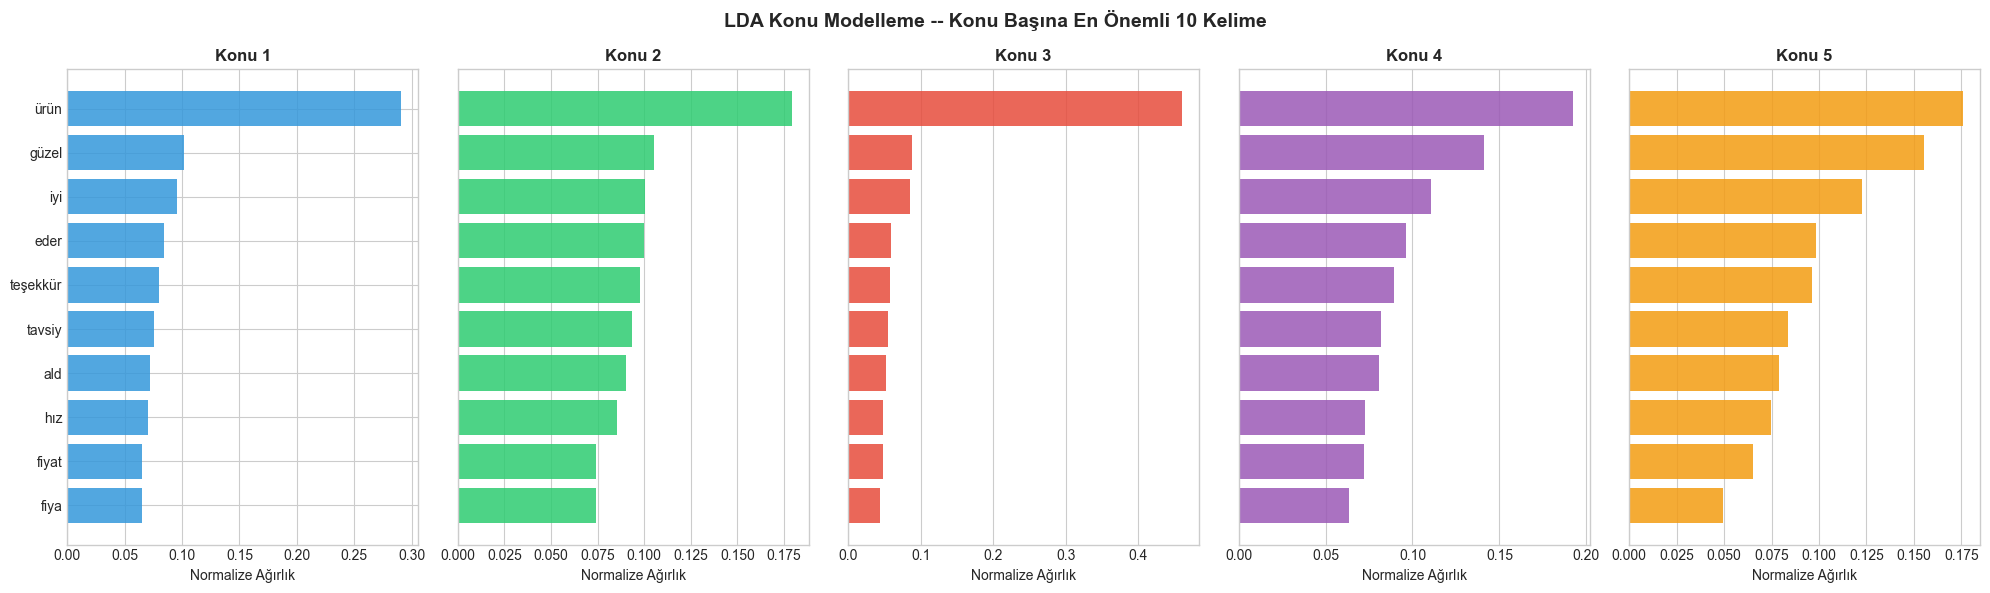

Duyguya göre ortalama konu dağılımı:
         Konu 1  Konu 2  Konu 3  Konu 4  Konu 5
duygu                                          
Nötr      0.156   0.272   0.241   0.160   0.171
Olumlu    0.436   0.145   0.154   0.160   0.105
Olumsuz   0.169   0.139   0.387   0.146   0.158


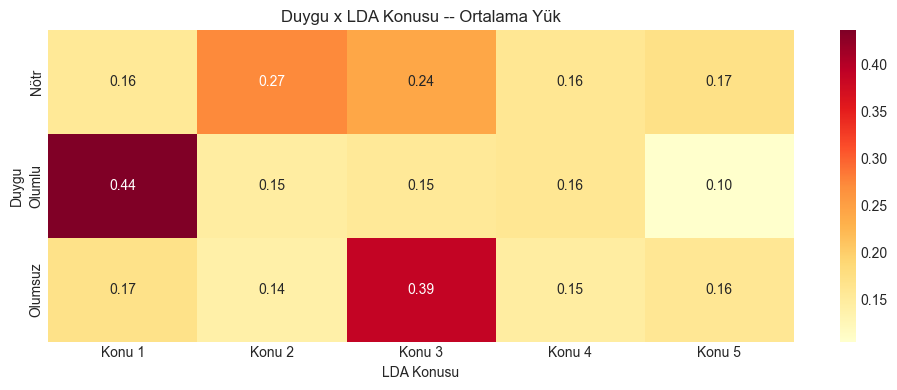

In [14]:
# LDA Konu-Kelime görselleştirmesi
fig, axes = plt.subplots(1, N_KONU, figsize=(20, 6), sharey=False)
fig.suptitle('LDA Konu Modelleme -- Konu Başına En Önemli 10 Kelime', fontsize=14, fontweight='bold')

renkler_lda = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
for konu_idx, konu_dagilimi in enumerate(lda_model.components_):
    ust_10_idx = konu_dagilimi.argsort()[::-1][:10]
    ust_10_kelimeler = [lda_ozellikler[i] for i in ust_10_idx]
    ust_10_agirliklar = konu_dagilimi[ust_10_idx]
    ust_10_agirliklar = ust_10_agirliklar / ust_10_agirliklar.sum()
    axes[konu_idx].barh(
        ust_10_kelimeler[::-1], ust_10_agirliklar[::-1],
        color=renkler_lda[konu_idx], alpha=0.85
    )
    axes[konu_idx].set_title(f'Konu {konu_idx + 1}', fontweight='bold')
    axes[konu_idx].set_xlabel('Normalize Ağırlık')
    if konu_idx > 0:
        axes[konu_idx].set_yticks([])
plt.tight_layout()
plt.show()

# Belge-konu dağılımı (LDA alt örneklem üzerinde)
belge_konu = lda_model.transform(X_lda)
belge_konu_df = pd.DataFrame(
    belge_konu,
    columns=[f'Konu {i+1}' for i in range(N_KONU)]
)
belge_konu_df['duygu'] = df_lda['duygu'].values

print('Duyguya göre ortalama konu dağılımı:')
print(belge_konu_df.groupby('duygu')[[f'Konu {i+1}' for i in range(N_KONU)]].mean().round(3))

fig, ax = plt.subplots(figsize=(10, 4))
konu_duygu = belge_konu_df.groupby('duygu')[[f'Konu {i+1}' for i in range(N_KONU)]].mean()
sns.heatmap(konu_duygu, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Duygu x LDA Konusu -- Ortalama Yük')
ax.set_ylabel('Duygu')
ax.set_xlabel('LDA Konusu')
plt.tight_layout()
plt.show()

---
## 8. Model Yorumlanabilirliği (Model Interpretability)

Bir NLP modelinin güvenilir olması için **neden** bu kararı verdiğini anlamamız gerekir:

- **Karmaşıklık Matrisi:** Hangi sınıflar birbirine karıştırılıyor?
- **Özellik Önemi:** Hangi kelimeler hangi sınıfı en çok etkiliyor?
- **Kelime Bulutları:** Pozitif ve negatif yorumlardaki kelime dağılımı


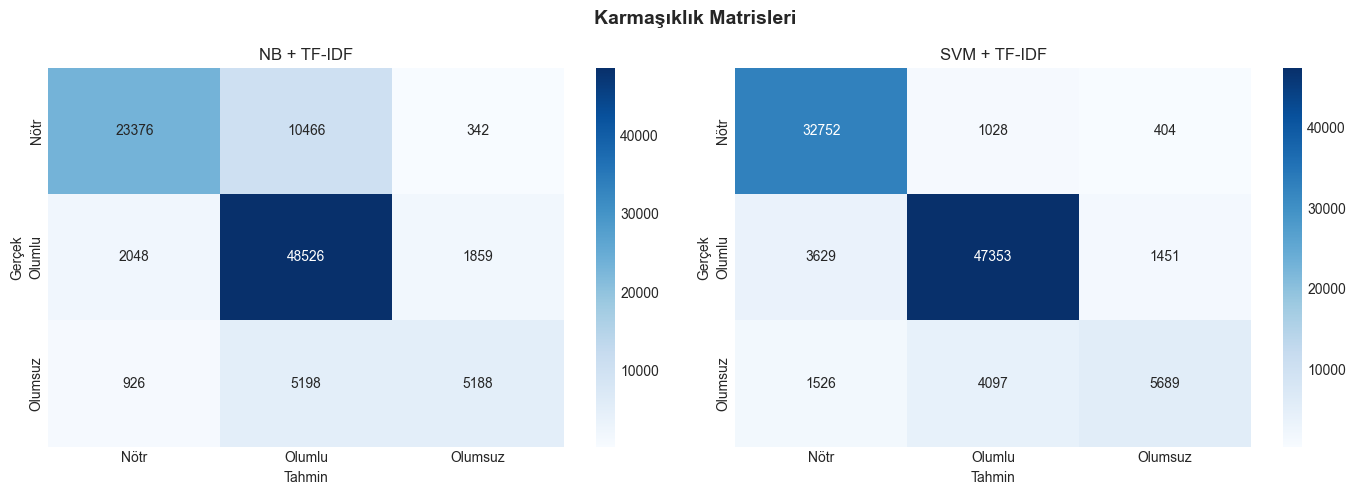

In [15]:
# ===== KARMAŞIKLIK MATRİSLERİ =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Karmaşıklık Matrisleri', fontsize=14, fontweight='bold')

for ax, (isim, y_pred) in zip(axes, [
    ('NB + TF-IDF', y_pred_nb_tfidf),
    ('SVM + TF-IDF', y_pred_svm_tfidf),
]):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(isim)
    ax.set_ylabel('Gerçek')
    ax.set_xlabel('Tahmin')

plt.tight_layout()
plt.show()

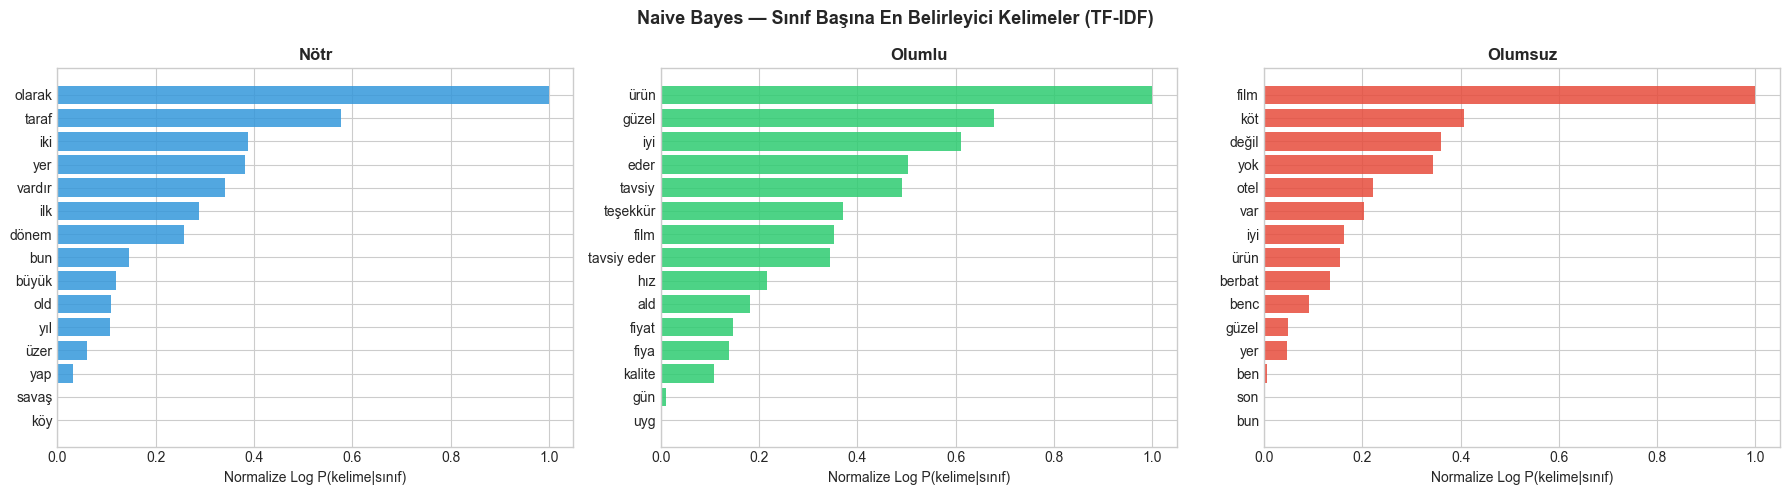

In [16]:
# ===== NAIVE BAYES ÖZELLIK ÖNEMİ =====
# Her sınıf için en belirleyici kelimeler
fig, axes = plt.subplots(1, len(le.classes_), figsize=(18, 5))
fig.suptitle('Naive Bayes — Sınıf Başına En Belirleyici Kelimeler (TF-IDF)', fontsize=13, fontweight='bold')

renkler_sinif = {'Nötr': '#3498db', 'Olumlu': '#2ecc71', 'Olumsuz': '#e74c3c'}

for idx, sinif in enumerate(le.classes_):
    log_proba = nb_tfidf.feature_log_prob_[idx]
    en_onemli_idx = log_proba.argsort()[::-1][:15]
    kelimeler_s = tfidf_vec.get_feature_names_out()[en_onemli_idx]
    skorlar_s = log_proba[en_onemli_idx]
    # Normalize
    skorlar_s = skorlar_s - skorlar_s.min()
    skorlar_s = skorlar_s / skorlar_s.max()

    axes[idx].barh(kelimeler_s[::-1], skorlar_s[::-1],
                   color=renkler_sinif.get(sinif, '#95a5a6'), alpha=0.85)
    axes[idx].set_title(f'{sinif}', fontweight='bold')
    axes[idx].set_xlabel('Normalize Log P(kelime|sınıf)')

plt.tight_layout()
plt.show()

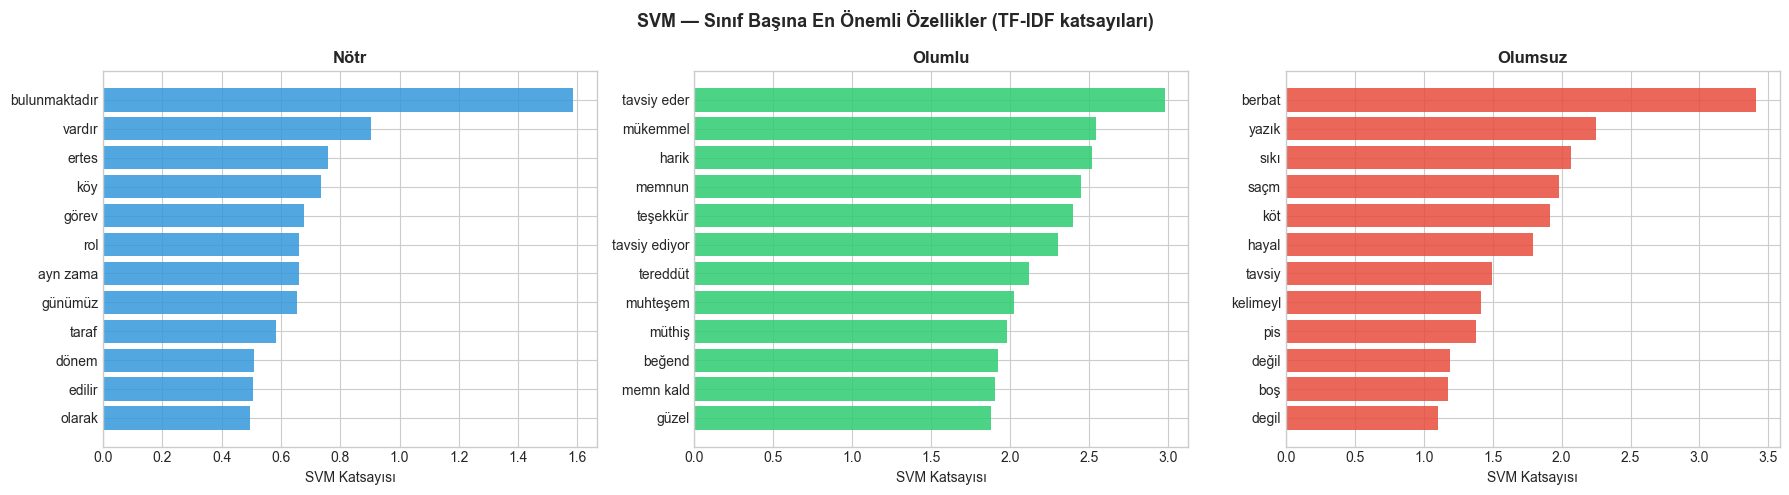

In [17]:
# ===== SVM ÖZELLIK ÖNEMİ =====
fig, axes = plt.subplots(1, len(le.classes_), figsize=(18, 5))
fig.suptitle('SVM — Sınıf Başına En Önemli Özellikler (TF-IDF katsayıları)', fontsize=13, fontweight='bold')

for idx, sinif in enumerate(le.classes_):
    katsayilar = svm_tfidf.coef_[idx]
    en_onemli_pos = katsayilar.argsort()[::-1][:12]
    kelimeler_pos = tfidf_vec.get_feature_names_out()[en_onemli_pos]
    katsayilar_pos = katsayilar[en_onemli_pos]

    axes[idx].barh(kelimeler_pos[::-1], katsayilar_pos[::-1],
                   color=renkler_sinif.get(sinif, '#95a5a6'), alpha=0.85)
    axes[idx].set_title(f'{sinif}', fontweight='bold')
    axes[idx].set_xlabel('SVM Katsayısı')
    axes[idx].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

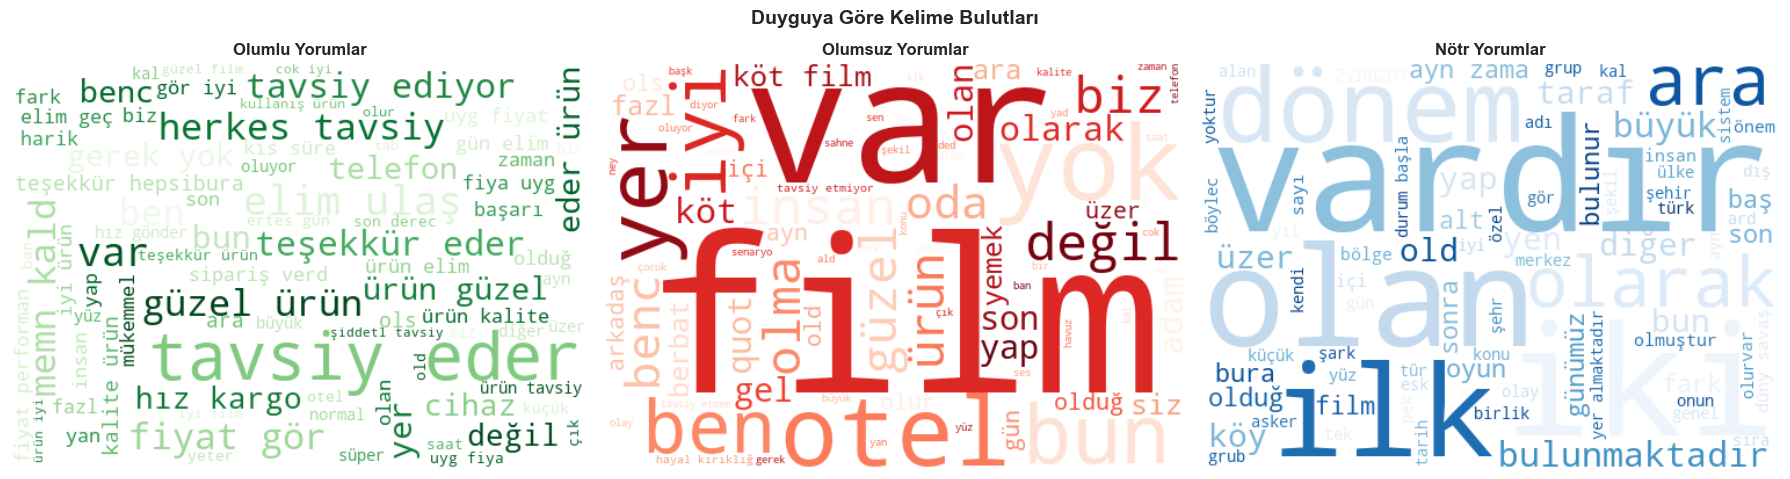

In [18]:
# ===== KELİME BULUTLARI =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Duyguya Göre Kelime Bulutları', fontsize=14, fontweight='bold')

wc_renkler = {'Olumlu': 'Greens', 'Olumsuz': 'Reds', 'Nötr': 'Blues'}

for ax, duygu in zip(axes, ['Olumlu', 'Olumsuz', 'Nötr']):
    metin_birlesmis = ' '.join(df[df['duygu'] == duygu]['islenmis'])
    if not metin_birlesmis.strip():
        ax.set_title(f'{duygu} (veri yok)')
        continue
    wc = WordCloud(
        width=500, height=350,
        background_color='white',
        colormap=wc_renkler[duygu],
        max_words=80,
        prefer_horizontal=0.8,
    ).generate(metin_birlesmis)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{duygu} Yorumlar', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

---
## 9. Sonuçlar ve Değerlendirme

Tüm modellerin karşılaştırmalı özeti ve Türkçe NLP için çıkarımlar.


=== MODEL KARŞILAŞTIRMA TABLOSU ===
       Model Test Doğruluğu CV Ortalama CV Std
   SVM + BoW          0.878       0.878  0.001
SVM + TF-IDF          0.876       0.875  0.001
 NB + TF-IDF          0.787       0.786  0.001
    NB + BoW          0.777       0.776  0.002


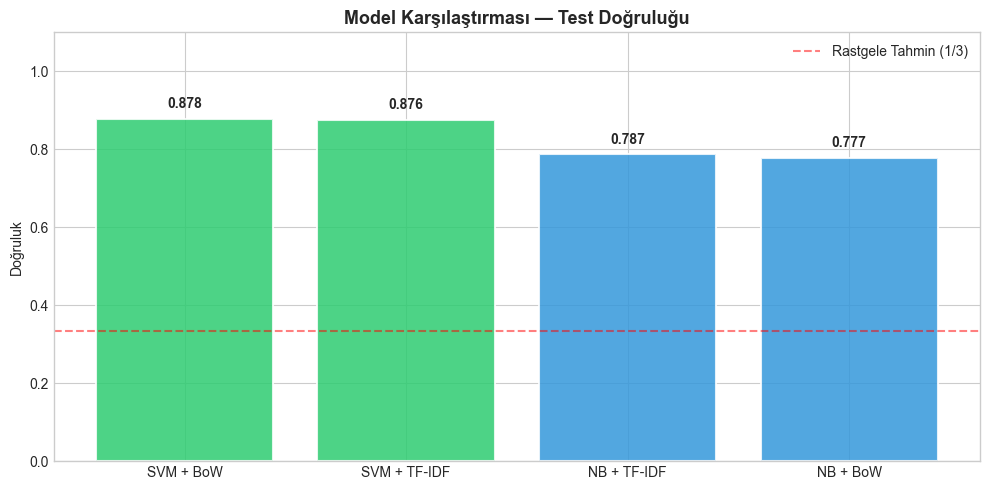

In [19]:
# ===== MODEL KARŞILAŞTIRMA TABLOSU =====
karsilastirma = pd.DataFrame([
    {
        'Model': isim,
        'Test Doğruluğu': f'{s["test_acc"]:.3f}',
        'CV Ortalama': f'{s["cv_mean"]:.3f}',
        'CV Std': f'{s["cv_std"]:.3f}',
    }
    for isim, s in sonuclar.items()
])

karsilastirma = karsilastirma.sort_values('Test Doğruluğu', ascending=False).reset_index(drop=True)
print('=== MODEL KARŞILAŞTIRMA TABLOSU ===')
print(karsilastirma.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
renkler_model = ['#2ecc71' if 'SVM' in m else '#3498db' for m in karsilastirma['Model']]
bars = ax.bar(
    karsilastirma['Model'],
    karsilastirma['Test Doğruluğu'].astype(float),
    color=renkler_model, alpha=0.85, edgecolor='white', linewidth=1.5
)
ax.set_title('Model Karşılaştırması — Test Doğruluğu', fontsize=13, fontweight='bold')
ax.set_ylabel('Doğruluk')
ax.set_ylim(0, 1.1)
ax.axhline(1/3, color='red', linestyle='--', alpha=0.5, label='Rastgele Tahmin (1/3)')
ax.legend()
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
en_iyi_model = karsilastirma.iloc[0]
en_iyi_acc = float(en_iyi_model["Test Doğruluğu"])

satirlar = [
    "=== PROJE ÖZET BULGULARI ===",
    "",
    "1. VERİ SETİ",
    f"   - {len(df)} Türkçe müşteri yorumu (gerçek veri)",
    "   - Kaynak: Hugging Face winvoker/turkish-sentiment-analysis-dataset",
    "   - 3 duygu sınıfı: Olumlu, Olumsuz, Nötr",
    f"   - Ortalama yorum uzunluğu: {df["kelime_sayisi"].mean():.1f} kelime",
    "",
    "2. ÖN İŞLEME",
    f"   - {len(turkce_durak)} durak kelime kaldırıldı (NLTK + özel liste)",
    "   - Sonek tabanlı Türkçe köke indirme uygulandı",
    "",
    "3. ÖZELLİK ÇIKARIMI",
    f"   - BoW: {X_bow.shape[1]} özellik (1-2 gram)",
    f"   - TF-IDF: {X_tfidf.shape[1]} özellik (1-2 gram)",
    "",
    "4. DUYGU ANALİZİ",
    f"   - En iyi model: {en_iyi_model["Model"]}",
    f"   - Test dogruluğu: {en_iyi_acc:.1%} (rastgele: {1/3:.1%})",
    "",
    "5. KONU MODELLEMESİ (LDA)",
    "   - 5 konu çıkarıldı",
    "",
    "6. TÜRKÇE NLP ZORLUKLARI",
    "   - Çekimli dil: Kök ayırma karmaşık ama kritik",
    "   - İroni tespiti zor (örn. Harika, tam beklediğim gibi bozuldu)",
    "   - Çözüm: BERTurk, mBERT, XLM-RoBERTa gibi transformer modelleri",
]
for s in satirlar:
    print(s)


=== PROJE ÖZET BULGULARI ===

1. VERİ SETİ
   - 489644 Türkçe müşteri yorumu (gerçek veri)
   - Kaynak: Hugging Face winvoker/turkish-sentiment-analysis-dataset
   - 3 duygu sınıfı: Olumlu, Olumsuz, Nötr
   - Ortalama yorum uzunluğu: 19.7 kelime

2. ÖN İŞLEME
   - 99 durak kelime kaldırıldı (NLTK + özel liste)
   - Sonek tabanlı Türkçe köke indirme uygulandı

3. ÖZELLİK ÇIKARIMI
   - BoW: 500 özellik (1-2 gram)
   - TF-IDF: 500 özellik (1-2 gram)

4. DUYGU ANALİZİ
   - En iyi model: SVM + BoW
   - Test dogruluğu: 87.8% (rastgele: 33.3%)

5. KONU MODELLEMESİ (LDA)
   - 5 konu çıkarıldı

6. TÜRKÇE NLP ZORLUKLARI
   - Çekimli dil: Kök ayırma karmaşık ama kritik
   - İroni tespiti zor (örn. Harika, tam beklediğim gibi bozuldu)
   - Çözüm: BERTurk, mBERT, XLM-RoBERTa gibi transformer modelleri
